Connected to env_stage (Python 3.11.15)

In [ ]:
import sys
import matlab.engine
from pathlib import Path
import re

user      = 'laptop'
name_file = 'dataset'
name_data = 'dataset_test'
# NETWORK   = 'BE_Unet'
NETWORK   = 'U-net'


if NETWORK=='BE_Unet':
    N_in=1
else:
    N_in=3

if user == 'laptop':
    BASE = Path(r'C:\Users\maxen\Documents\Stage')
elif user == 'server':
    BASE = Path(r'D:\Maxence\Stage-M1---UPV')

DATA_PATH       = BASE / 'HeavyFiles' / 'data' / (name_data + '.mat')
RESULTS_DIR     = BASE / 'Software' / 'OT_NN' / 'Pytorch_NN' / 'results'/ NETWORK 
BEST_PATH       = RESULTS_DIR / name_file / ('unet_' + name_file + '_best.pth')

sys.path.append(str(BASE / 'Software' / 'OT_NN' / 'Pytorch_NN'))
sys.path.append(str(BASE / 'Software' / 'OT_Functions'))
sys.path.append(str(BASE / 'Software' / 'OT_Software'))

import torch
import numpy as np
from model         import *
from dataset       import *
from topology_utils import *

In [ ]:
IMG_SIZE = 32
PENAL    = 3
RMIN     = 1.5
NGPpL    = 2
NGPpS    = 9
E        = 1000
NU       = 0.3

In [ ]:
if NETWORK=='BE_Unet':
    model = BE_UNetTopo(nif=32, n_in=N_in, n_out=3, use_cbam=True,embed_n1=32, embed_out=64)
elif NETWORK=='U-net':
    model = UNetTopo(nif=32, n_in=N_in, n_out=3, use_cbam=True)
else:
    raise ValueError("Invalid NETWORK value. Choose 'U-net' or 'BE_Unet'.")

state_dict = torch.load(
    BEST_PATH,
    map_location='cpu'
)

model.load_state_dict(state_dict)
model.eval()

UNetTopo(
  (inc): TripleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): TripleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

In [ ]:
data    = load_mat(DATA_PATH)
ds_base = Dataset_TopOpt(data)
ds_filtre = ds_base.filtre_dataset(rho_min=0.15, rho_max=0.85)
IterData_FEM = IterationDataset(ds_filtre)

List_List_iterations=[]

In [ ]:
eng = matlab.engine.start_matlab()
eng.addpath(str(BASE / 'Software' / 'OT_Functions'))
eng.addpath(str(BASE / 'Software' / 'OT_Software'))

mesh_path = str(BASE / 'Software' / 'OT_Software' / 'Square.msh')
eng.eval(f"MeshData = ReadGMSH('{mesh_path}');", nargout=0)
eng.eval("D = DHooks2D(1000, 0.3, 'Plane Stress');", nargout=0)

In [ ]:
List_List_count_FEM = []

ID_distrib = 0


# Only Unet, Only FEM, Decreasing compliance, n Unet - m FEM
List_iterations, List_count_FEM = run_topology_optimization(
    ds_filtre, 
    ID_distrib, 
    eng, model, 
    N_in=N_in,
    N_max_iterations = 100, 
    RULE='Decreasing compliance', 
    # RULE='Only Unet',
    TYPE_FIRST='FEM',
    )


List_List_iterations.append(List_iterations)
List_List_count_FEM.append(List_count_FEM)

i=3 — TYPE=UNet — sample.c=0.001487
converged=False
c <= final: False

i=4 — TYPE=FEM — sample.c=0.001806
converged=False
c <= final: False

i=5 — TYPE=FEM — sample.c=0.001640
converged=False
c <= final: False

i=6 — TYPE=FEM — sample.c=0.001514
converged=False
c <= final: False

i=7 — TYPE=FEM — sample.c=0.001415
converged=False
c <= final: False

i=8 — TYPE=FEM — sample.c=0.001316
converged=False
c <= final: False

i=9 — TYPE=FEM — sample.c=0.001241
converged=False
c <= final: False

i=10 — TYPE=FEM — sample.c=0.001173
converged=False
c <= final: False

i=11 — TYPE=FEM — sample.c=0.001127
converged=False
c <= final: False

i=12 — TYPE=FEM — sample.c=0.001084
converged=False
c <= final: False

i=13 — TYPE=FEM — sample.c=0.001054
converged=False
c <= final: False

i=14 — TYPE=FEM — sample.c=0.001026
converged=False
c <= final: False

i=15 — TYPE=FEM — sample.c=0.001006
converged=False
c <= final: False

i=16 — TYPE=FEM — sample.c=0.000986
converged=False
c <= final: False

i=17 — TYPE=

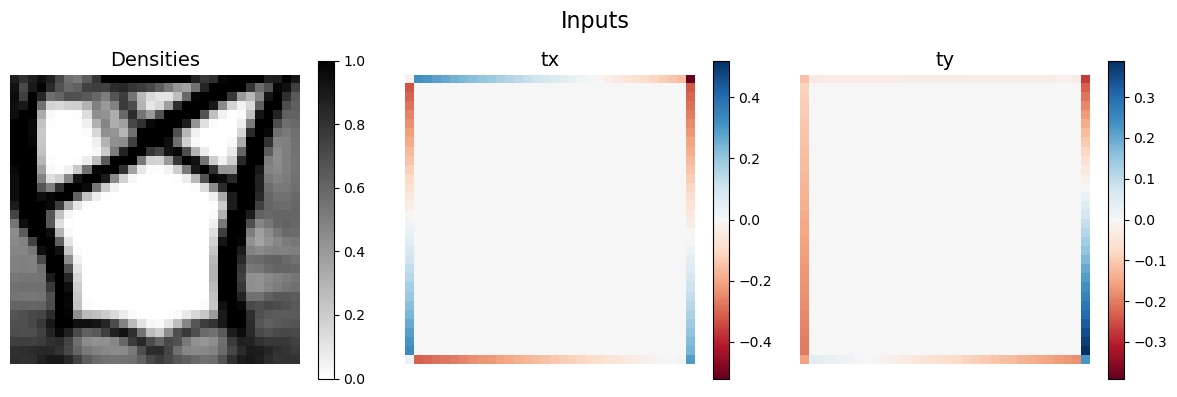

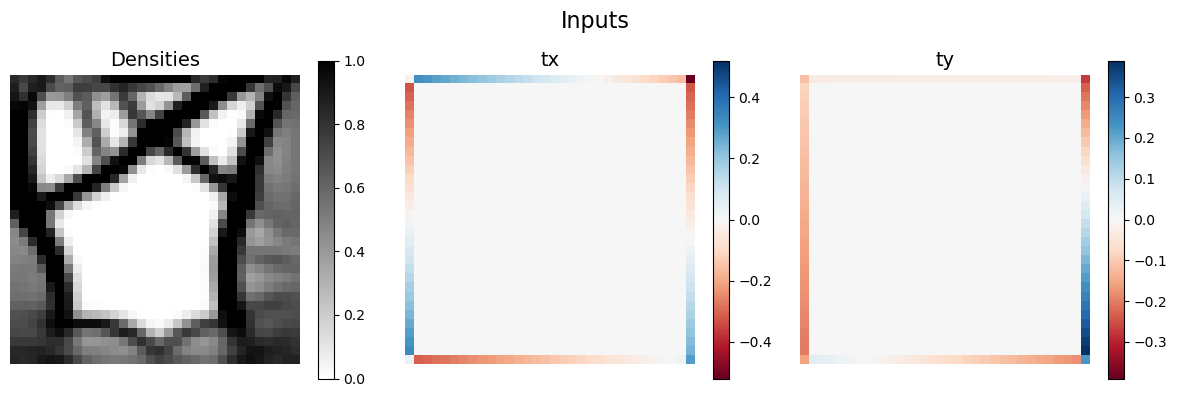

In [ ]:
idx_FEM_sol = IterData_FEM.last_iteration_index[ID_distrib]
FEM_sample  = IterationSample(IterData_FEM, idx_FEM_sol)


List_iterations[-1].plot_inputs()
FEM_sample.plot_inputs()

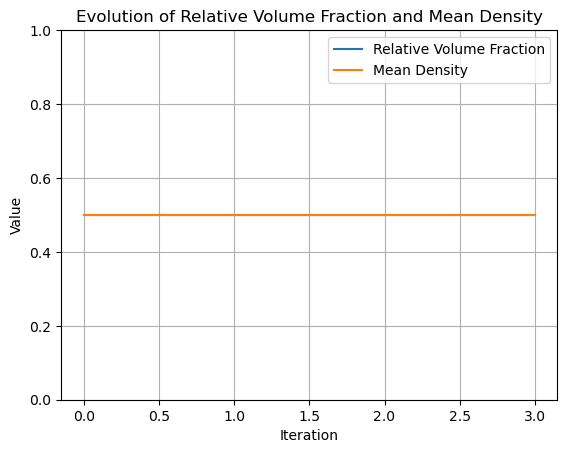

In [ ]:
List_Relative_Vol_Frac=[]
List_mean_densities=[]
for sample in List_iterations:
    List_Relative_Vol_Frac.append(sample.Relative_Vol_Frac)
    List_mean_densities.append(sample.Densities.numpy().mean())

plt.figure()
plt.plot(List_Relative_Vol_Frac, label='Relative Volume Fraction')
plt.plot(List_mean_densities, label='Mean Density')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Evolution of Relative Volume Fraction and Mean Density')
plt.legend()
plt.grid()
plt.ylim(0, 1) 
plt.show()

ValueError: x and y must have same first dimension, but have shapes (26,) and (2,)

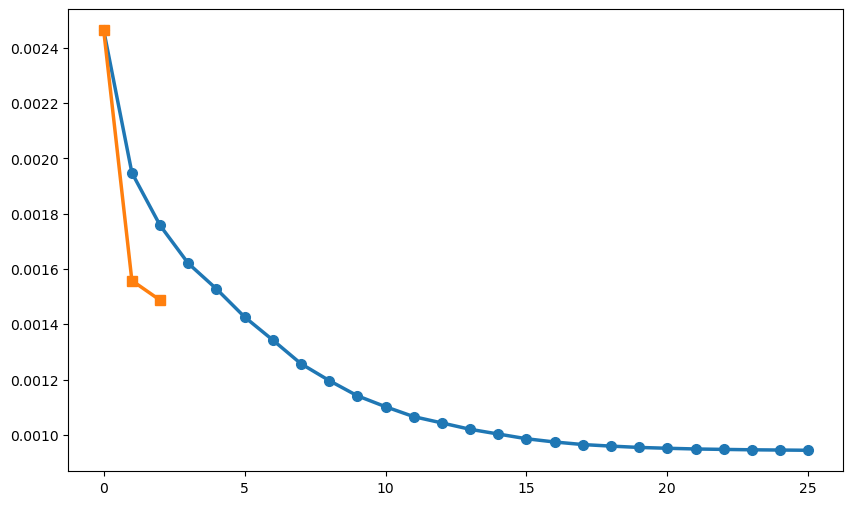

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


NameError: name 'RULE' is not defined

In [ ]:
RULE='Decreasing Compliance'

In [ ]:


List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


NameError: name 'TYPE_FIRST' is not defined

In [ ]:
TYPE_FIRST='UNet'

In [ ]:


List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    



NameError: name 'N_max_iterations' is not defined

In [ ]:
N_max_iterations=100

In [ ]:


List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    



i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

i=12 — TYPE=UNet — sample.c=0.001308
converged=False
c <= final: False

i=13 — TYPE=UNet — sample.c=0.001323
converged=False
c <= final: False

i=14 — TYPE=UNet — sample.c=0.001354
converged=False
c <= final: False

i=15 — TYPE=UNet — sample.c=0.001364
converged=False
c <= final: False

i=16 — TYPE=UNet — sample.c=0.001344
converged=False
c <= final: False


In [ ]:
List_count_FEM

[]

In [ ]:
len(List_iterations)

71

In [ ]:
f_text=1.25 # text size multiplicator 


FEM_c=[]
UNet_c=[]

for i in range(len(IterationDataset_FEM)):
    sample=IterationSample(IterationDataset_FEM, i)
    FEM_c.append([i,sample.c])

FEM_step_c=[]

for i,sample in enumerate(List_Iterations_Unet):
    UNet_c.append([i, sample.c])
    if i in List_count_FEM:
        FEM_step_c.append(sample.c)

FEM_c=np.array(FEM_c)
UNet_c=np.array(UNet_c)

plt.figure(figsize=(10, 6))
plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')
plt.plot(List_count_FEM, FEM_step_c, 'rs', markersize=7, label = 'FEM steps')

plt.xlabel('Iterations', fontsize=f_text*14,)
plt.ylabel('Compliance', fontsize=f_text*14, )
plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
plt.legend(fontsize=f_text*13)
plt.grid(True, alpha=0.3)

# Set x-axis ticks: integers only, step of 5
max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
plt.yticks(fontsize=f_text*12)
plt.tight_layout()
plt.show()


NameError: name 'IterationDataset_FEM' is not defined

In [ ]:
IterationDataset_FEM=IterData_FEM

In [ ]:
f_text=1.25 # text size multiplicator 


FEM_c=[]
UNet_c=[]

for i in range(len(IterationDataset_FEM)):
    sample=IterationSample(IterationDataset_FEM, i)
    FEM_c.append([i,sample.c])

FEM_step_c=[]

for i,sample in enumerate(List_Iterations_Unet):
    UNet_c.append([i, sample.c])
    if i in List_count_FEM:
        FEM_step_c.append(sample.c)

FEM_c=np.array(FEM_c)
UNet_c=np.array(UNet_c)

plt.figure(figsize=(10, 6))
plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')
plt.plot(List_count_FEM, FEM_step_c, 'rs', markersize=7, label = 'FEM steps')

plt.xlabel('Iterations', fontsize=f_text*14,)
plt.ylabel('Compliance', fontsize=f_text*14, )
plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
plt.legend(fontsize=f_text*13)
plt.grid(True, alpha=0.3)

# Set x-axis ticks: integers only, step of 5
max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
plt.yticks(fontsize=f_text*12)
plt.tight_layout()
plt.show()


NameError: name 'List_Iterations_Unet' is not defined

In [ ]:
List_Iterations_Unet=List_iterations

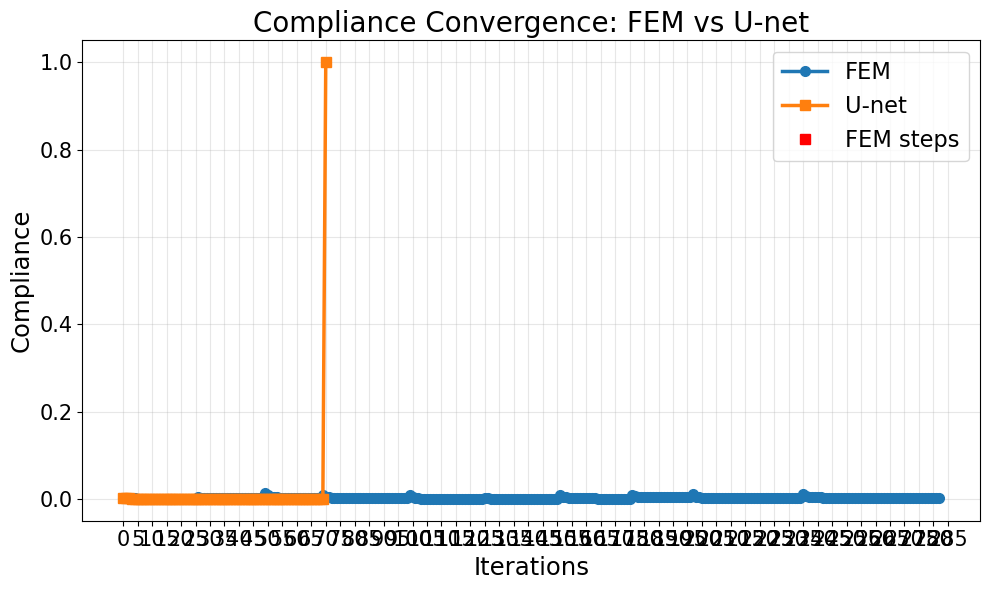

In [ ]:
f_text=1.25 # text size multiplicator 


FEM_c=[]
UNet_c=[]

for i in range(len(IterationDataset_FEM)):
    sample=IterationSample(IterationDataset_FEM, i)
    FEM_c.append([i,sample.c])

FEM_step_c=[]

for i,sample in enumerate(List_Iterations_Unet):
    UNet_c.append([i, sample.c])
    if i in List_count_FEM:
        FEM_step_c.append(sample.c)

FEM_c=np.array(FEM_c)
UNet_c=np.array(UNet_c)

plt.figure(figsize=(10, 6))
plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')
plt.plot(List_count_FEM, FEM_step_c, 'rs', markersize=7, label = 'FEM steps')

plt.xlabel('Iterations', fontsize=f_text*14,)
plt.ylabel('Compliance', fontsize=f_text*14, )
plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
plt.legend(fontsize=f_text*13)
plt.grid(True, alpha=0.3)

# Set x-axis ticks: integers only, step of 5
max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
plt.yticks(fontsize=f_text*12)
plt.tight_layout()
plt.show()


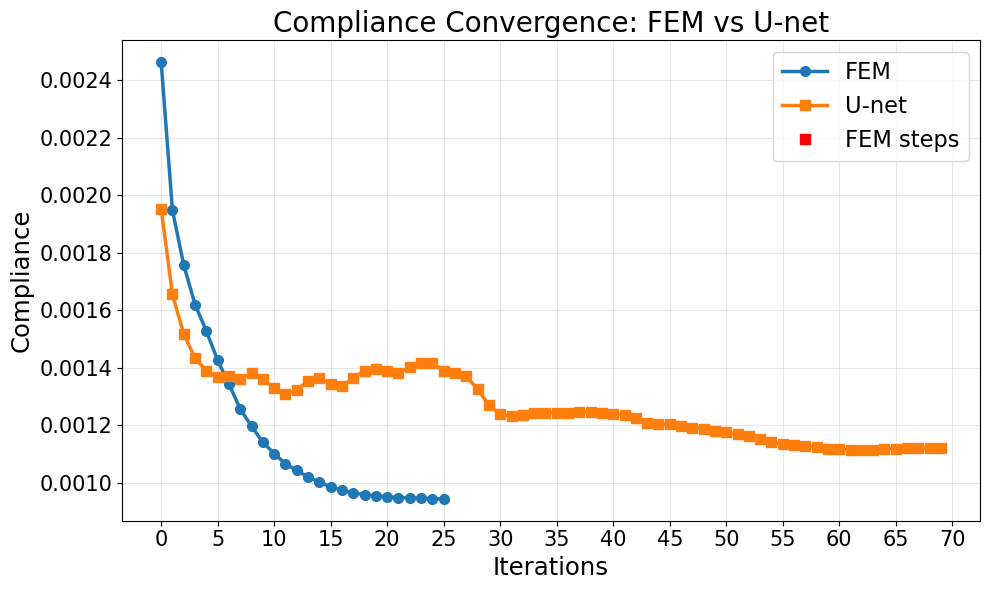

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
import sys
import matlab.engine
from pathlib import Path
import re

user      = 'laptop'
name_file = 'dataset'
name_data = 'dataset_test'
# NETWORK   = 'BE_Unet'
NETWORK   = 'U-net'


if NETWORK=='BE_Unet':
    N_in=1
else:
    N_in=3

if user == 'laptop':
    BASE = Path(r'C:\Users\maxen\Documents\Stage')
elif user == 'server':
    BASE = Path(r'D:\Maxence\Stage-M1---UPV')

DATA_PATH       = BASE / 'HeavyFiles' / 'data' / (name_data + '.mat')
RESULTS_DIR     = BASE / 'Software' / 'OT_NN' / 'Pytorch_NN' / 'results'/ NETWORK 
BEST_PATH       = RESULTS_DIR / name_file / ('unet_' + name_file + '_best.pth')

sys.path.append(str(BASE / 'Software' / 'OT_NN' / 'Pytorch_NN'))
sys.path.append(str(BASE / 'Software' / 'OT_Functions'))
sys.path.append(str(BASE / 'Software' / 'OT_Software'))

import torch
import numpy as np
from model         import *
from dataset       import *
from topology_utils import *

In [ ]:
IMG_SIZE = 32
PENAL    = 3
RMIN     = 1.5
NGPpL    = 2
NGPpS    = 9
E        = 1000
NU       = 0.3

In [ ]:
if NETWORK=='BE_Unet':
    model = BE_UNetTopo(nif=32, n_in=N_in, n_out=3, use_cbam=True,embed_n1=32, embed_out=64)
elif NETWORK=='U-net':
    model = UNetTopo(nif=32, n_in=N_in, n_out=3, use_cbam=True)
else:
    raise ValueError("Invalid NETWORK value. Choose 'U-net' or 'BE_Unet'.")

state_dict = torch.load(
    BEST_PATH,
    map_location='cpu'
)

model.load_state_dict(state_dict)
model.eval()

UNetTopo(
  (inc): TripleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): TripleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

In [ ]:
data    = load_mat(DATA_PATH)
ds_base = Dataset_TopOpt(data)
ds_filtre = ds_base.filtre_dataset(rho_min=0.15, rho_max=0.85)
IterData_FEM = IterationDataset(ds_filtre)

List_List_iterations=[]

In [ ]:
eng = matlab.engine.start_matlab()
eng.addpath(str(BASE / 'Software' / 'OT_Functions'))
eng.addpath(str(BASE / 'Software' / 'OT_Software'))

mesh_path = str(BASE / 'Software' / 'OT_Software' / 'Square.msh')
eng.eval(f"MeshData = ReadGMSH('{mesh_path}');", nargout=0)
eng.eval("D = DHooks2D(1000, 0.3, 'Plane Stress');", nargout=0)

In [ ]:
List_List_count_FEM = []

ID_distrib = 0


# Only Unet, Only FEM, Decreasing compliance, n Unet - m FEM
List_iterations, List_count_FEM = run_topology_optimization(
    ds_filtre, 
    ID_distrib, 
    eng, model, 
    N_in=N_in,
    N_max_iterations = 100, 
    RULE='Decreasing compliance', 
    # RULE='Only Unet',
    TYPE_FIRST='FEM',
    )


List_List_iterations.append(List_iterations)
List_List_count_FEM.append(List_count_FEM)

i=3 — TYPE=UNet — sample.c=0.001487
converged=False
c <= final: False

i=4 — TYPE=FEM — sample.c=0.001806
converged=False
c <= final: False

i=5 — TYPE=FEM — sample.c=0.001640
converged=False
c <= final: False

i=6 — TYPE=FEM — sample.c=0.001514
converged=False
c <= final: False

i=7 — TYPE=FEM — sample.c=0.001415
converged=False
c <= final: False

i=8 — TYPE=FEM — sample.c=0.001316
converged=False
c <= final: False

i=9 — TYPE=FEM — sample.c=0.001241
converged=False
c <= final: False

i=10 — TYPE=FEM — sample.c=0.001173
converged=False
c <= final: False

i=11 — TYPE=FEM — sample.c=0.001127
converged=False
c <= final: False

i=12 — TYPE=FEM — sample.c=0.001084
converged=False
c <= final: False

i=13 — TYPE=FEM — sample.c=0.001054
converged=False
c <= final: False

i=14 — TYPE=FEM — sample.c=0.001026
converged=False
c <= final: False

i=15 — TYPE=FEM — sample.c=0.001006
converged=False
c <= final: False

i=16 — TYPE=FEM — sample.c=0.000986
converged=False
c <= final: False

i=17 — TYPE=

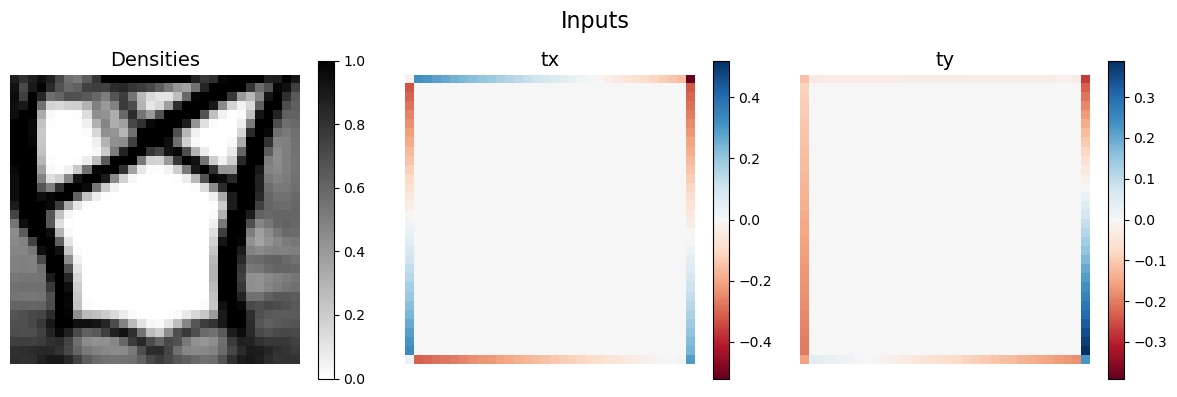

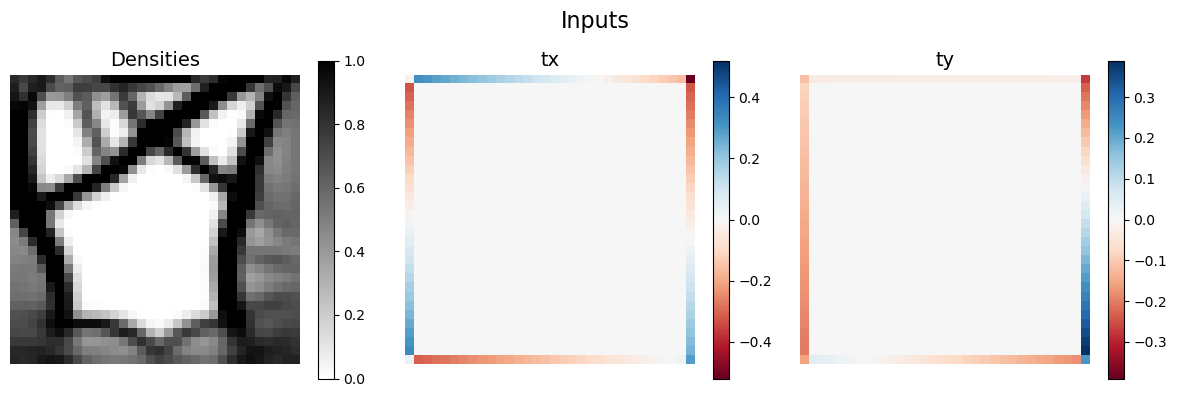

In [ ]:
idx_FEM_sol = IterData_FEM.last_iteration_index[ID_distrib]
FEM_sample  = IterationSample(IterData_FEM, idx_FEM_sol)


List_iterations[-1].plot_inputs()
FEM_sample.plot_inputs()

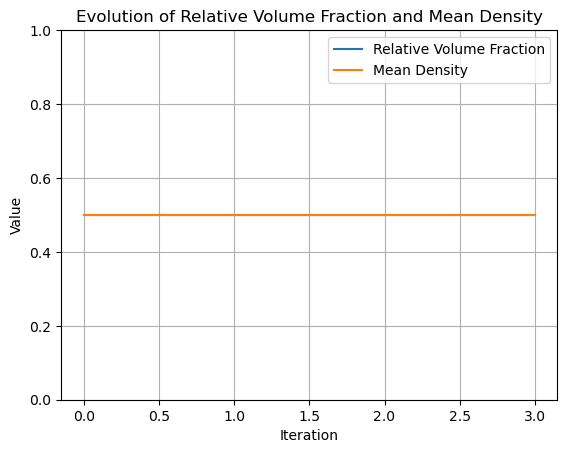

In [ ]:
List_Relative_Vol_Frac=[]
List_mean_densities=[]
for sample in List_iterations:
    List_Relative_Vol_Frac.append(sample.Relative_Vol_Frac)
    List_mean_densities.append(sample.Densities.numpy().mean())

plt.figure()
plt.plot(List_Relative_Vol_Frac, label='Relative Volume Fraction')
plt.plot(List_mean_densities, label='Mean Density')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Evolution of Relative Volume Fraction and Mean Density')
plt.legend()
plt.grid()
plt.ylim(0, 1) 
plt.show()

ValueError: x and y must have same first dimension, but have shapes (26,) and (2,)

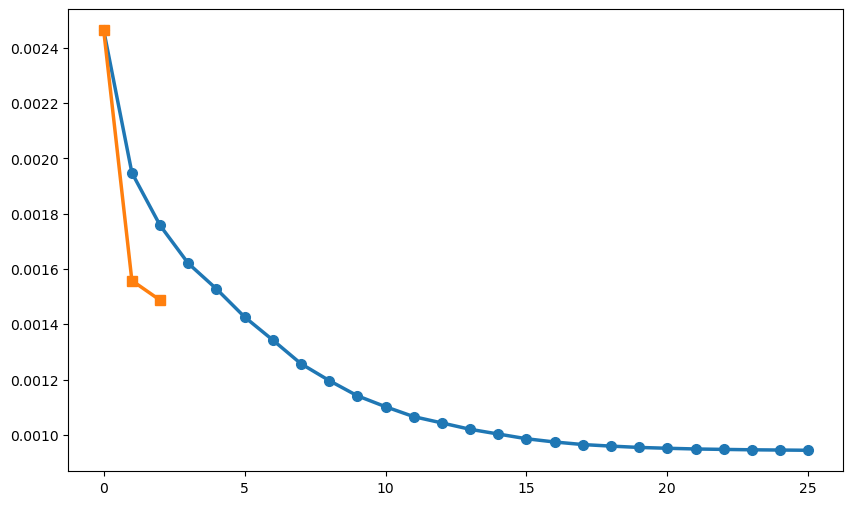

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

ValueError: x and y must have same first dimension, but have shapes (26,) and (2,)

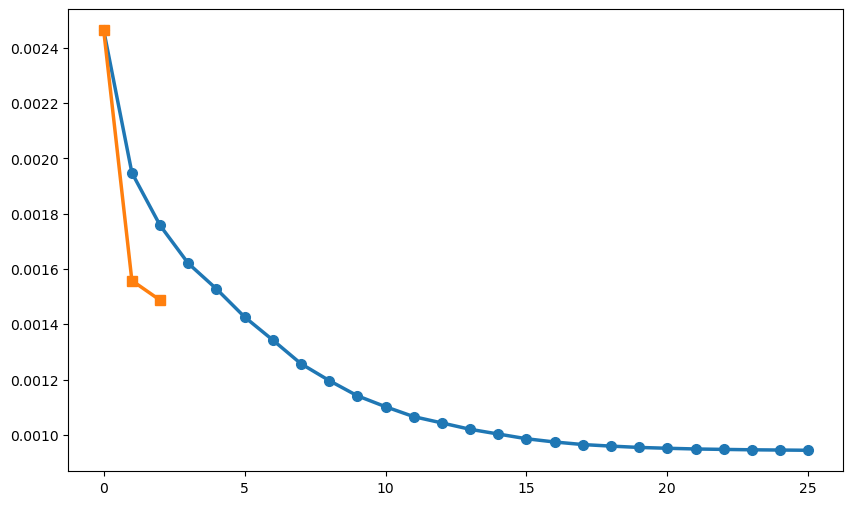

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
FEM_c

array([[0.00000000e+00, 2.46286346e-03],
       [1.00000000e+00, 1.94774813e-03],
       [2.00000000e+00, 1.75750186e-03],
       [3.00000000e+00, 1.62005448e-03],
       [4.00000000e+00, 1.52786658e-03],
       [5.00000000e+00, 1.42627989e-03],
       [6.00000000e+00, 1.34285132e-03],
       [7.00000000e+00, 1.25723518e-03],
       [8.00000000e+00, 1.19649118e-03],
       [9.00000000e+00, 1.14133686e-03],
       [1.00000000e+01, 1.10179547e-03],
       [1.10000000e+01, 1.06594351e-03],
       [1.20000000e+01, 1.04314846e-03],
       [1.30000000e+01, 1.02021359e-03],
       [1.40000000e+01, 1.00306526e-03],
       [1.50000000e+01, 9.85994004e-04],
       [1.60000000e+01, 9.74243740e-04],
       [1.70000000e+01, 9.64999024e-04],
       [1.80000000e+01, 9.59340308e-04],
       [1.90000000e+01, 9.54586489e-04],
       [2.00000000e+01, 9.51579248e-04],
       [2.10000000e+01, 9.49016947e-04],
       [2.20000000e+01, 9.47457447e-04],
       [2.30000000e+01, 9.46029497e-04],
       [2.400000

In [ ]:
List_count_FEM

[0,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26]

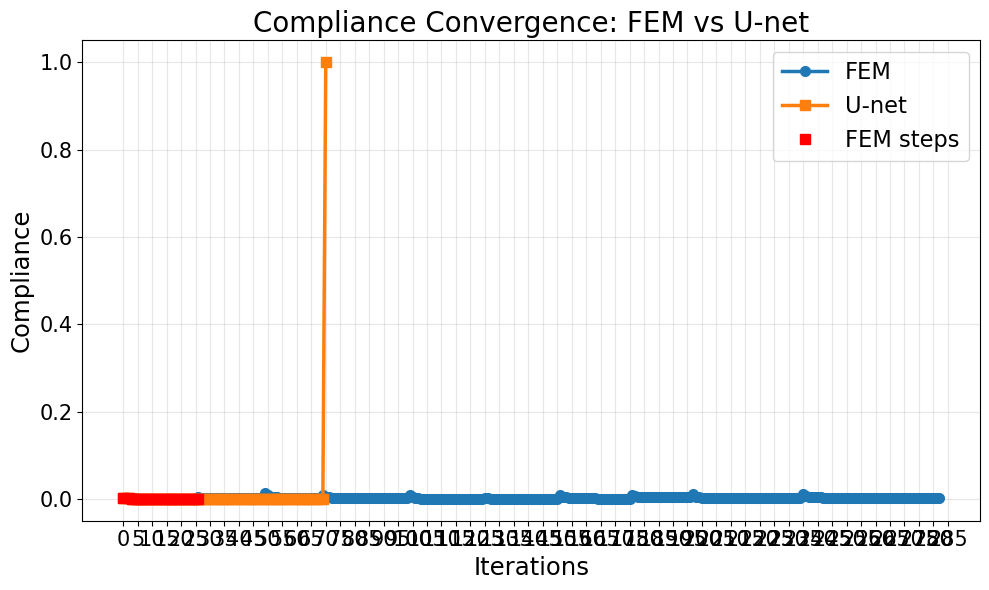

In [ ]:
f_text=1.25 # text size multiplicator 


FEM_c=[]
UNet_c=[]

for i in range(len(IterationDataset_FEM)):
    sample=IterationSample(IterationDataset_FEM, i)
    FEM_c.append([i,sample.c])

FEM_step_c=[]

for i,sample in enumerate(List_Iterations_Unet):
    UNet_c.append([i, sample.c.item()])
    if i in List_count_FEM:
        FEM_step_c.append((i, sample.c.item()))

FEM_c=np.array(FEM_c)
UNet_c=np.array(UNet_c)

plt.figure(figsize=(10, 6))
plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')

FEM_step_c=np.array(FEM_step_c)

plt.plot(FEM_step_c[:, 0], FEM_step_c[:, 1], 'rs', markersize=7, label = 'FEM steps')

plt.xlabel('Iterations', fontsize=f_text*14,)
plt.ylabel('Compliance', fontsize=f_text*14, )
plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
plt.legend(fontsize=f_text*13)
plt.grid(True, alpha=0.3)

# Set x-axis ticks: integers only, step of 5
max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
plt.yticks(fontsize=f_text*12)
plt.tight_layout()
plt.show()


In [ ]:
def visualize_convergence(List_Iterations_Unet, IterationDataset_FEM, List_count_FEM, NETWORK:str, PLOT=True,):
    f_text=1.25 # text size multiplicator 


    FEM_c=[]
    UNet_c=[]

    for i in range(len(IterationDataset_FEM)):
        sample=IterationSample(IterationDataset_FEM, i)
        FEM_c.append([i,sample.c])

    FEM_step_c=[]

    for i,sample in enumerate(List_Iterations_Unet):
        UNet_c.append([i, sample.c.item()])
        if i in List_count_FEM:
            FEM_step_c.append((i, sample.c.item()))

    FEM_c=np.array(FEM_c)
    UNet_c=np.array(UNet_c)

    plt.figure(figsize=(10, 6))
    plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
    plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')
    
    FEM_step_c=np.array(FEM_step_c)

    plt.plot(FEM_step_c[:, 0], FEM_step_c[:, 1], 'rs', markersize=7, label = 'FEM steps')
    
    plt.xlabel('Iterations', fontsize=f_text*14,)
    plt.ylabel('Compliance', fontsize=f_text*14, )
    plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
    plt.legend(fontsize=f_text*13)
    plt.grid(True, alpha=0.3)

    # Set x-axis ticks: integers only, step of 5
    max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
    plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
    plt.yticks(fontsize=f_text*12)
    plt.tight_layout()
    plt.show()

    return FEM_c, UNet_c


def statistical_convergence(List_List_Iterations_UNet, IterData_FEM:IterationDataset, NETWORK='U-Net', PLOT=True, TYPE='std'):
    '''
    Returns the mean evolution of the compliance.
    '''
    IterData_Unet=list_to_IterationDataset(List_List_Iterations_UNet[0])

    for i in range(1, len(List_List_Iterations_UNet)):
        IterData_Unet += list_to_IterationDataset(List_List_Iterations_UNet[i])


    Variation_c = []

    for IterData in [IterData_FEM, IterData_Unet]: 
        c_array = IterData.dataset.c  # object array (N,), each element is (1, n_iter)

        N_max = max(c_array[i].flatten().shape[0] for i in range(len(c_array)))

        dict_c = {j: [] for j in range(N_max)}

        for i in range(len(c_array)):
            c_i = c_array[i].flatten()
            c0  = c_i.max()  # compliance at index 1
            for j in range(len(c_i)):
                dict_c[j].append(float(c_i[j]/c0))

        tab_c = []
        for key in dict_c.keys():
            mean = np.mean(dict_c[key])
            std  = np.std(dict_c[key])
            number = len(dict_c[key])
            tab_c.append((mean, std, number))

        Variation_c.append(tab_c)

    FEM_c, UNet_c = Variation_c

    if PLOT:
        fig, ax = plt.subplots(figsize=(10, 5))

        labels = ['FEM', NETWORK]
        colors = ['tab:blue', 'tab:orange']

        for k, (tab_c, label, color) in enumerate(zip(Variation_c, labels, colors)):
            means = [mean for mean, std, number in tab_c[2:]]
            stds  = [std  for mean, std, number in tab_c[2:]]
            LENS = [number for mean, std, number in tab_c[2:]]

            LENS = [n / max(LENS) for n in LENS]

            ax.plot(means, label=label, color=color)

            if TYPE == 'std':
                ax.fill_between(range(len(means)),
                                [m - s for m, s in zip(means, stds)],
                                [m + s for m, s in zip(means, stds)],
                                alpha=0.3, color=color)
            elif TYPE == 'lenght':
                ax.fill_between(range(len(means)),
                                [m - l/len(Variation_c) for m, l in zip(means, LENS)],
                                [m + l/len(Variation_c) for m, l in zip(means, LENS)],
                                alpha=0.3, color=color)


        ax.set_xlabel('Iteration')
        ax.set_ylabel('c / c_max')
        ax.set_title(f'Compliance convergence - mean and {TYPE} across distributions')
        ax.legend()
        ax.grid()
        ax.set_xlim(0, 100)
        plt.tight_layout()
        plt.show()

    return FEM_c, UNet_c

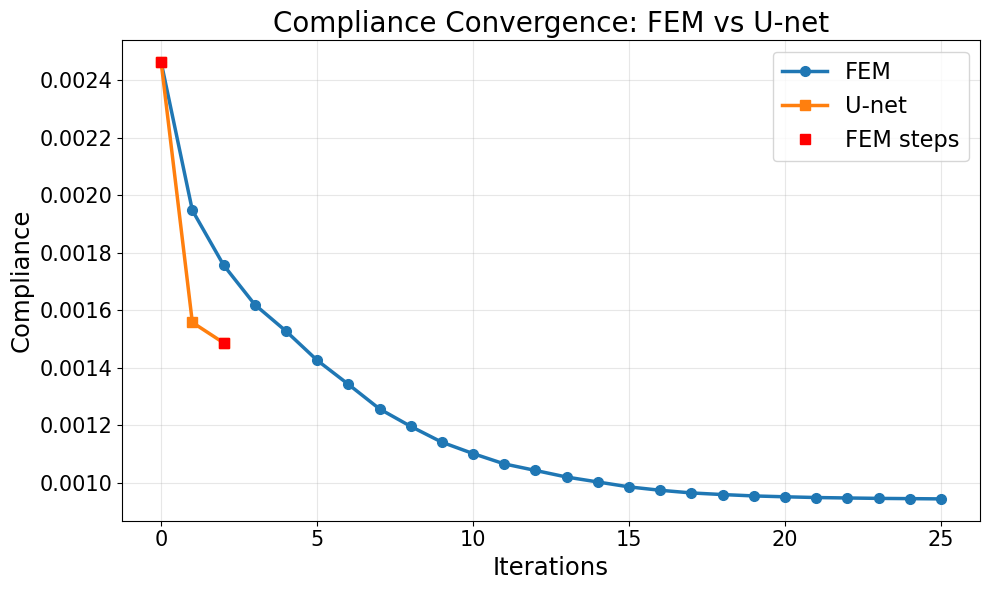

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
UNet_c

array([[0.00000000e+00, 2.46286346e-03],
       [1.00000000e+00, 1.55788392e-03],
       [2.00000000e+00, 1.48705824e-03]])

In [ ]:
def run_topology_optimization(ds_filtre, ID_distrib, eng, model, N_in=3,N_max_iterations = 100, RULE=' ', TYPE_FIRST='FEM', max_FEM_iterations=10):
    
    List_count_FEM=[]

    # compliance at last iteration of the FEM solution
    final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

    # Rule to alternate between U-Net and FEM iterations
    match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
    if match_Periodic:
        n_unet = int(match_Periodic.group(1))
        m_fem  = int(match_Periodic.group(2))
        
    match_Unet = re.match('Only Unet', RULE) # only Unet iterations
    match_FEM = re.match('Only FEM', RULE) # only FEM iterations
    match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

    ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
    sample = IterationSample(ds_iter, 0)

    List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
    List_mean_densities = [sample.Densities.numpy().mean()]
    
    
    #% Run first topology optimization
    next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())

    List_iterations  = [sample, next_sample]
    i                = 1

    # Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
    sample=next_sample

    if TYPE_FIRST == 'FEM':
        List_count_FEM.append(0)

    if match_FEM:
        NEXT_TYPE='FEM'
    else:
        NEXT_TYPE='UNet'

    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1


    # loop until max iterations, convergence, or reaching final compliance
    while (i < N_max_iterations 
           and (sample.c.item() > final_compliance)
           and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
           ): 
        
        sample      = next_sample

        if match_FEM:
            NEXT_TYPE='FEM'
            List_count_FEM.append(i)

        elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
            for j in range(m_fem):
                next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
                List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                List_mean_densities.append(next_sample.Densities.numpy().mean())
                List_iterations.append(next_sample)
                i += 1
                List_count_FEM.append(i)

        elif (match_decreasing 
            and i>2
            ):
            if sample.c.item() > List_iterations[-3].c.item():
                NEXT_TYPE='FEM'
                
                if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                    # Ckeck if last iteration was already FEM
                    if List_count_FEM[-1]==i-1: 
                        # if last iteration was already FEM, do not delete it but just do another FEM iteration
                        List_count_FEM.append(i)

                    else: 
                        # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                        del List_iterations[-1] 
                        del List_Relative_Vol_Frac[-1]
                        del List_mean_densities[-1]
                        List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                        next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                        List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                        List_mean_densities.append(next_sample.Densities.numpy().mean())
                        List_iterations.append(next_sample)
        i += 1
            else:
                NEXT_TYPE='UNet'
    

        else:
            NEXT_TYPE='UNet'

        # Common actualisation for both UNet and FEM iterations
        next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
        List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
        List_mean_densities.append(next_sample.Densities.numpy().mean())
        List_iterations.append(next_sample)
        i += 1
        print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
        print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
        print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
        

    return List_iterations, List_count_FEM 

IndentationError: unexpected indent (<ipython-input-41-15984d14e8c5>, line 98)

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

i=12 — TYPE=UNet — sample.c=0.001308
converged=False
c <= final: False

i=13 — TYPE=UNet — sample.c=0.001323
converged=False
c <= final: False

i=14 — TYPE=UNet — sample.c=0.001354
converged=False
c <= final: False

i=15 — TYPE=UNet — sample.c=0.001364
converged=False
c <= final: False

i=16 — TYPE=UNet — sample.c=0.001344
converged=False
c <= final: False


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

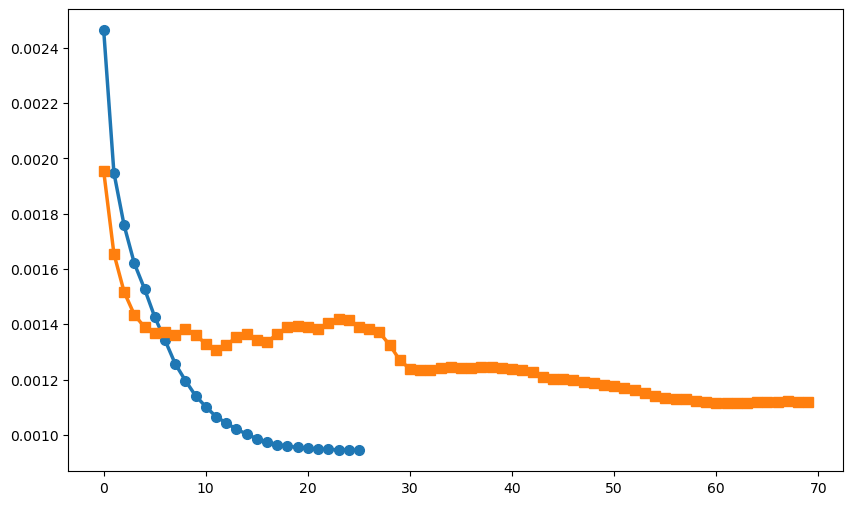

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
List_count_FEM

[]

In [ ]:
FEM_step_c

array([[0.00000000e+00, 1.95335597e-03],
       [2.00000000e+00, 1.51677080e-03],
       [3.00000000e+00, 1.43436994e-03],
       [4.00000000e+00, 1.38957659e-03],
       [5.00000000e+00, 1.36705150e-03],
       [6.00000000e+00, 1.37195876e-03],
       [7.00000000e+00, 1.36051245e-03],
       [8.00000000e+00, 1.38296816e-03],
       [9.00000000e+00, 1.36266428e-03],
       [1.00000000e+01, 1.32826110e-03],
       [1.10000000e+01, 1.30803580e-03],
       [1.20000000e+01, 1.32317643e-03],
       [1.30000000e+01, 1.35410717e-03],
       [1.40000000e+01, 1.36374356e-03],
       [1.50000000e+01, 1.34356564e-03],
       [1.60000000e+01, 1.33566326e-03],
       [1.70000000e+01, 1.36479386e-03],
       [1.80000000e+01, 1.39040500e-03],
       [1.90000000e+01, 1.39465486e-03],
       [2.00000000e+01, 1.38873444e-03],
       [2.10000000e+01, 1.38270587e-03],
       [2.20000000e+01, 1.40286924e-03],
       [2.30000000e+01, 1.41849089e-03],
       [2.40000000e+01, 1.41681253e-03],
       [2.500000

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

i=12 — TYPE=UNet — sample.c=0.001308
converged=False
c <= final: False

i=13 — TYPE=UNet — sample.c=0.001323
converged=False
c <= final: False

i=14 — TYPE=UNet — sample.c=0.001354
converged=False
c <= final: False

i=15 — TYPE=UNet — sample.c=0.001364
converged=False
c <= final: False

i=16 — TYPE=UNet — sample.c=0.001344
converged=False
c <= final: False


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

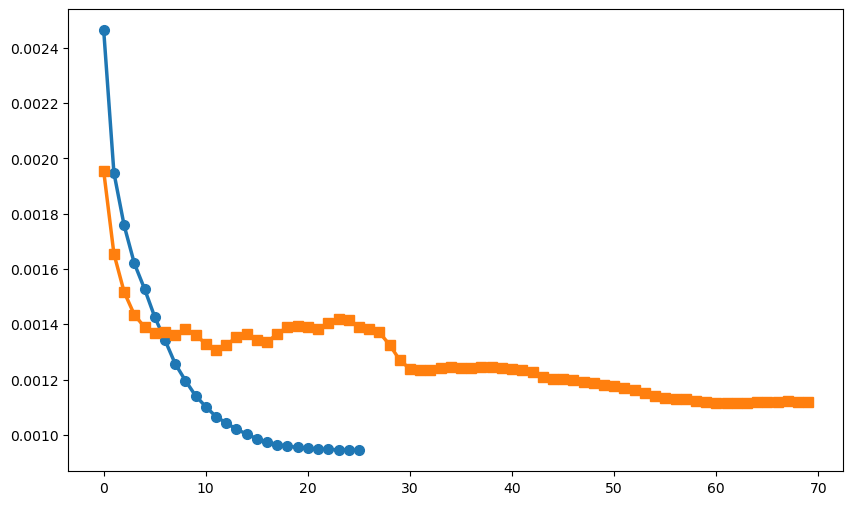

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

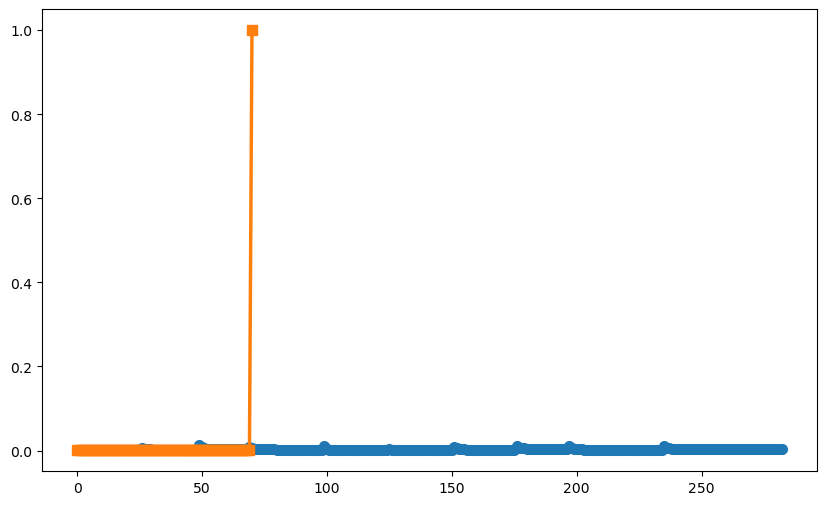

In [ ]:
f_text=1.25 # text size multiplicator 


FEM_c=[]
UNet_c=[]

for i in range(len(IterationDataset_FEM)):
    sample=IterationSample(IterationDataset_FEM, i)
    FEM_c.append([i,sample.c])

FEM_step_c=[]

for i,sample in enumerate(List_Iterations_Unet):
    UNet_c.append([i, sample.c.item()])
    if i in List_count_FEM:
        FEM_step_c.append((i, sample.c.item()))

FEM_c=np.array(FEM_c)
UNet_c=np.array(UNet_c)

plt.figure(figsize=(10, 6))
plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')

FEM_step_c=np.array(FEM_step_c)

plt.plot(FEM_step_c[:, 0], FEM_step_c[:, 1], 'rs', markersize=7, label = 'FEM steps')

plt.xlabel('Iterations', fontsize=f_text*14,)
plt.ylabel('Compliance', fontsize=f_text*14, )
plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
plt.legend(fontsize=f_text*13)
plt.grid(True, alpha=0.3)

# Set x-axis ticks: integers only, step of 5
max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
plt.yticks(fontsize=f_text*12)
plt.tight_layout()
plt.show()


In [ ]:
FEM_step_c

array([], dtype=float64)

In [ ]:
List_count_FEM

[]

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

i=12 — TYPE=UNet — sample.c=0.001308
converged=False
c <= final: False

i=13 — TYPE=UNet — sample.c=0.001323
converged=False
c <= final: False

i=14 — TYPE=UNet — sample.c=0.001354
converged=False
c <= final: False

i=15 — TYPE=UNet — sample.c=0.001364
converged=False
c <= final: False

i=16 — TYPE=UNet — sample.c=0.001344
converged=False
c <= final: False


In [ ]:
RULE

'Decreasing Compliance'

In [ ]:
RULE='Decreasing compliance'

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item():
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[]
i=4 — TYPE=FEM — sample.c=0.002082
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3]
i=5 — TYPE=FEM — sample.c=0.001722
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4]
i=6 — TYPE=FEM — sample.c=0.001571
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5]
i=7 — TYPE=FEM — sample.c=0.001480
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6]
i=8 — TYPE=FEM — sample.c=0.001399
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6, 7]
i=9 — TYPE=FEM — sample.c=0.001337
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5

In [ ]:
List_count_FEM

[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

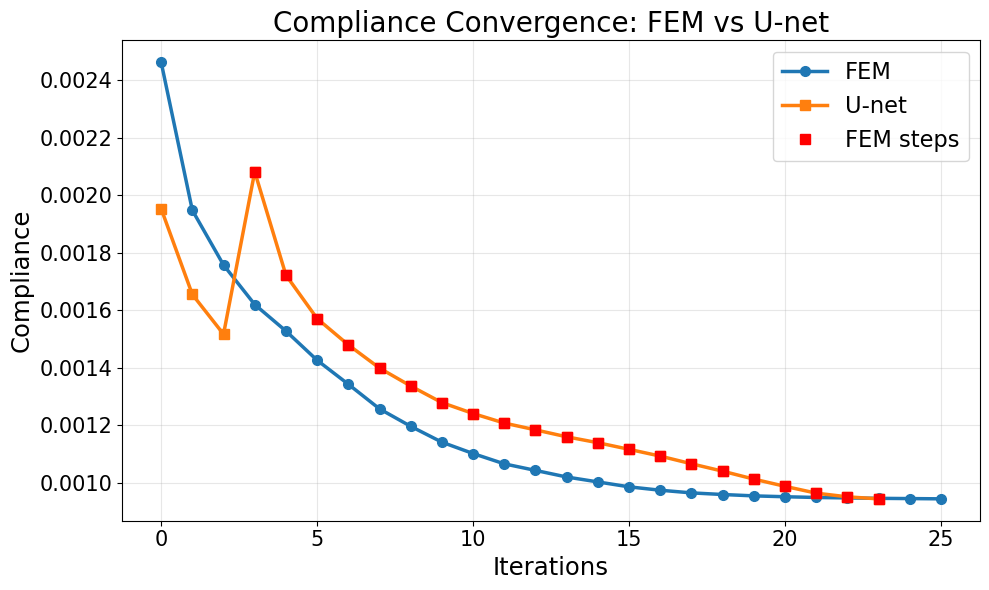

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
threshold=0.1

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item() * (1 + threshold):
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[]
i=4 — TYPE=FEM — sample.c=0.002082
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3]
i=5 — TYPE=FEM — sample.c=0.001722
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4]
i=6 — TYPE=FEM — sample.c=0.001571
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5]
i=7 — TYPE=FEM — sample.c=0.001480
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6]
i=8 — TYPE=FEM — sample.c=0.001399
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6, 7]
i=9 — TYPE=FEM — sample.c=0.001337
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5

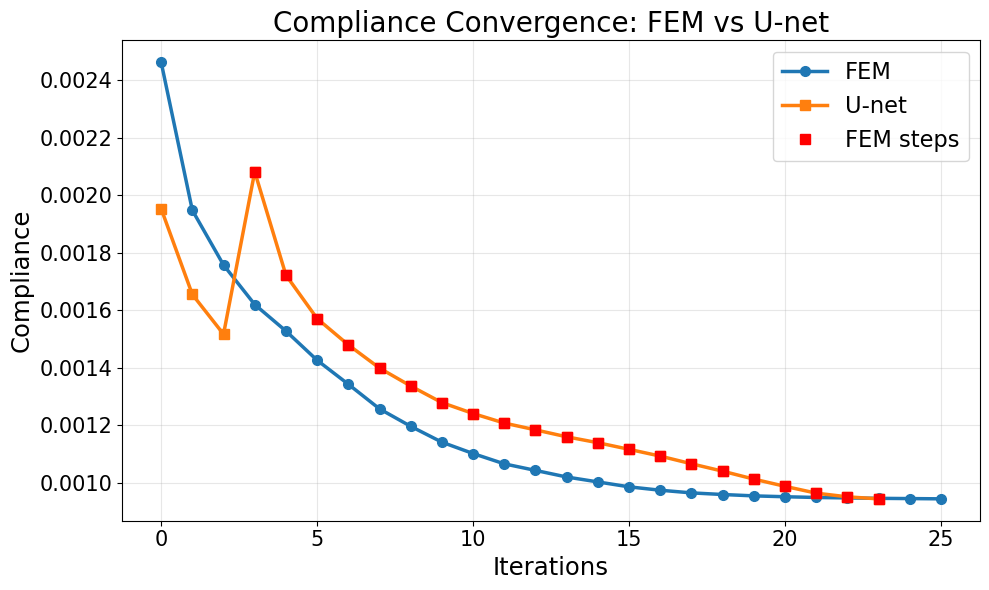

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
threshold=0.5

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item() * (1 + threshold):
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[]
i=4 — TYPE=FEM — sample.c=0.002082
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3]
i=5 — TYPE=FEM — sample.c=0.001722
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4]
i=6 — TYPE=FEM — sample.c=0.001571
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5]
i=7 — TYPE=FEM — sample.c=0.001480
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6]
i=8 — TYPE=FEM — sample.c=0.001399
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6, 7]
i=9 — TYPE=FEM — sample.c=0.001337
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5

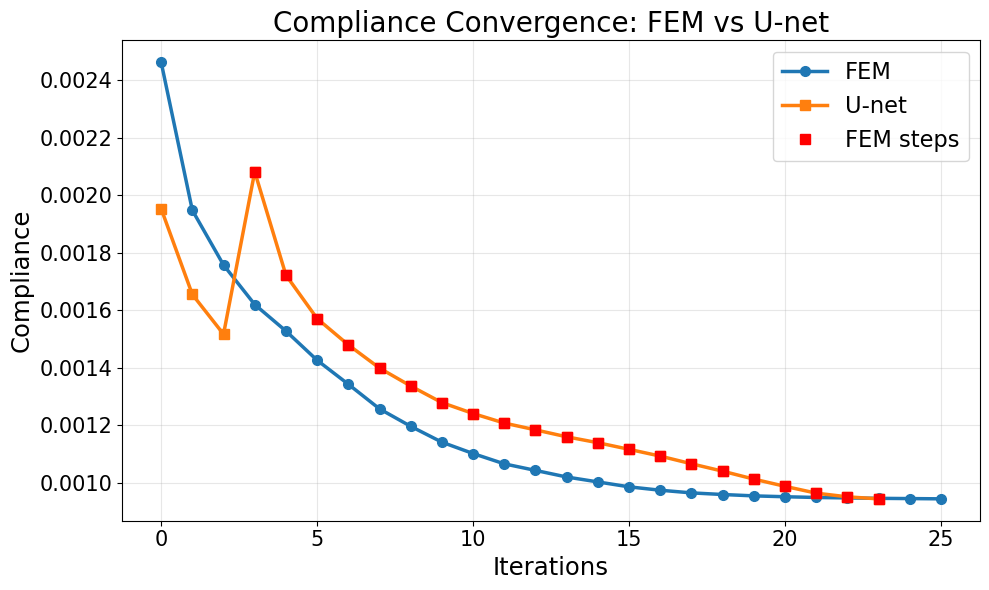

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
threshold=1

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)

    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item() * (1 + threshold):
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[]
i=4 — TYPE=FEM — sample.c=0.002082
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3]
i=5 — TYPE=FEM — sample.c=0.001722
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4]
i=6 — TYPE=FEM — sample.c=0.001571
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5]
i=7 — TYPE=FEM — sample.c=0.001480
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6]
i=8 — TYPE=FEM — sample.c=0.001399
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6, 7]
i=9 — TYPE=FEM — sample.c=0.001337
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5

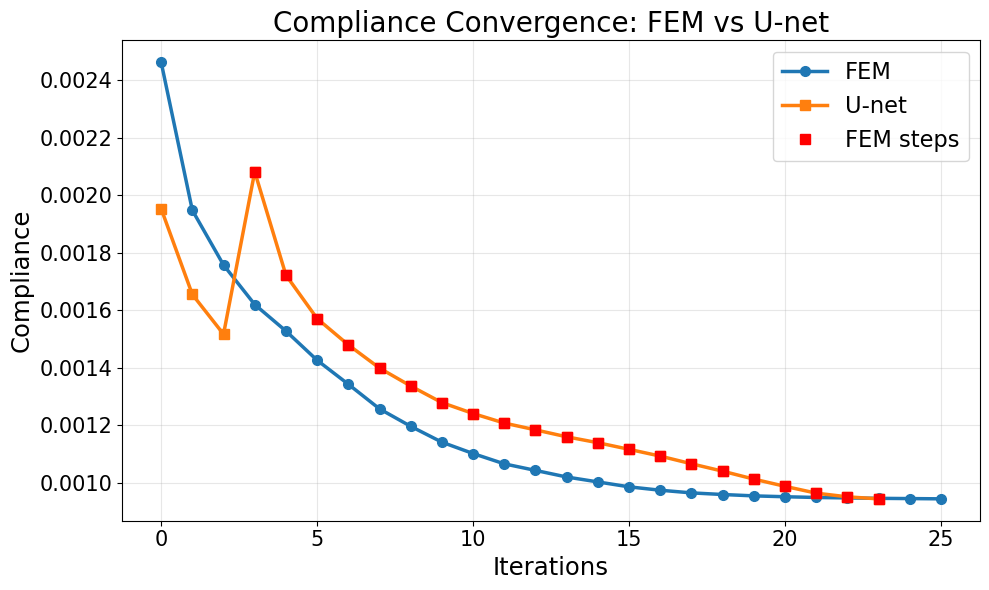

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample
print(f"  → sample.c={sample.c.item():.6f}  List_iterations[-3].c={List_iterations[-3].c.item():.6f}")
    
if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item() * (1 + threshold):
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

IndexError: list index out of range

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if i>2:
    print(f"  → sample.c={sample.c.item():.6f}  List_iterations[-3].c={List_iterations[-3].c.item():.6f}")
        
if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item() * (1 + threshold):
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[]
i=4 — TYPE=FEM — sample.c=0.002082
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3]
i=5 — TYPE=FEM — sample.c=0.001722
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4]
i=6 — TYPE=FEM — sample.c=0.001571
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5]
i=7 — TYPE=FEM — sample.c=0.001480
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6]
i=8 — TYPE=FEM — sample.c=0.001399
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6, 7]
i=9 — TYPE=FEM — sample.c=0.001337
converged=False
c <= final: False

  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


#% Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample

    
    if i>2:
        print(f"  → sample.c={sample.c.item():.6f}  List_iterations[-3].c={List_iterations[-3].c.item():.6f}")
        

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        if sample.c.item() > List_iterations[-3].c.item() * (1 + threshold):
            print(f"  → compliance augmente, NEXT_TYPE=FEM")
            print(f"  → List_count_FEM avant={List_count_FEM}")
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → sample.c=1.000000  List_iterations[-3].c=0.001655
  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[]
i=4 — TYPE=FEM — sample.c=0.002082
converged=False
c <= final: False

  → sample.c=1.000000  List_iterations[-3].c=0.001517
  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3]
i=5 — TYPE=FEM — sample.c=0.001722
converged=False
c <= final: False

  → sample.c=1.000000  List_iterations[-3].c=0.002082
  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4]
i=6 — TYPE=FEM — sample.c=0.001571
converged=False
c <= final: False

  → sample.c=1.000000  List_iterations[-3].c=0.001722
  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5]
i=7 — TYPE=FEM — sample.c=0.001480
converged=False
c <= final: False

  → sample.c=1.000000  List_iterations[-3].c=0.001571
  → compliance augmente, NEXT_TYPE=FEM
  → List_count_FEM avant=[3, 4, 5, 6]
i=8 — TYPE=FEM — sampl

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


# Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample  

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        c_prev = List_iterations[-2].c.item()  # actualisé
        c_pprev = List_iterations[-3].c.item() # actualisé
        print(f"  → c_prev={c_prev:.6f}  c_pprev={c_pprev:.6f}")
        if c_prev > c_pprev * (1 + torch.threshold):
        
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    


i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → c_prev=0.001517  c_pprev=0.001655


TypeError: unsupported operand type(s) for +: 'int' and 'builtin_function_or_method'

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


# Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample  

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        c_prev = List_iterations[-2].c.item()  # actualisé
        c_pprev = List_iterations[-3].c.item() # actualisé
        print(f"  → c_prev={c_prev:.6f}  c_pprev={c_pprev:.6f}")
        if c_prev > c_pprev * (1 + threshold):
        
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → c_prev=0.001517  c_pprev=0.001655
i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

  → c_prev=0.001434  c_pprev=0.001517
i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

  → c_prev=0.001390  c_pprev=0.001434
i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

  → c_prev=0.001367  c_pprev=0.001390
i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

  → c_prev=0.001372  c_pprev=0.001367
i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

  → c_prev=0.001361  c_pprev=0.001372
i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

  → c_prev=0.001383  c_pprev=0.001361
i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

  → c_prev=0.001363  c_pprev=0.001383
i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

  → c_prev=0.001328  c_pprev=0.001363
i=12 — TYPE=UNet 

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

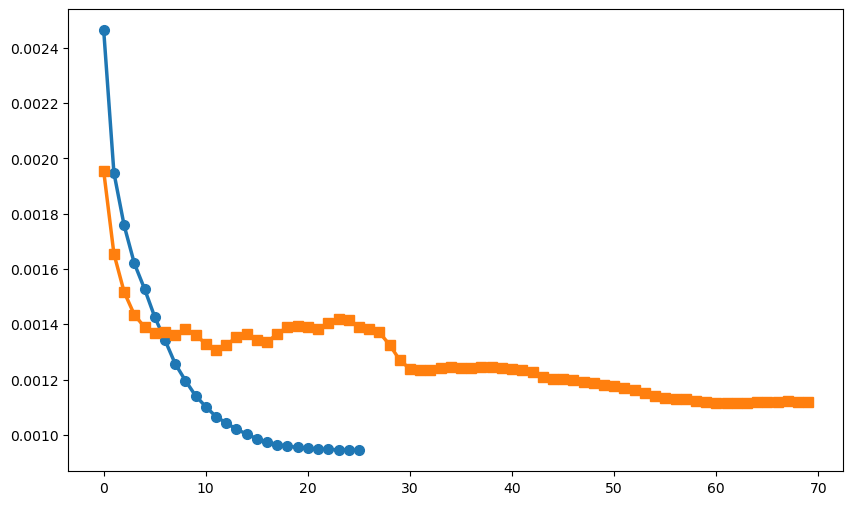

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
List_List_count_FEM

[[0,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26]]

In [ ]:
threshold

1

In [ ]:
List_count_FEM

[]

In [ ]:
threshold=0.1

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


# Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample  

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        c_prev = List_iterations[-2].c.item()  # actualisé
        c_pprev = List_iterations[-3].c.item() # actualisé
        print(f"  → c_prev={c_prev:.6f}  c_pprev={c_pprev:.6f}")
        if c_prev > c_pprev * (1 + threshold):
        
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → c_prev=0.001517  c_pprev=0.001655
i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

  → c_prev=0.001434  c_pprev=0.001517
i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

  → c_prev=0.001390  c_pprev=0.001434
i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

  → c_prev=0.001367  c_pprev=0.001390
i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

  → c_prev=0.001372  c_pprev=0.001367
i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

  → c_prev=0.001361  c_pprev=0.001372
i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

  → c_prev=0.001383  c_pprev=0.001361
i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

  → c_prev=0.001363  c_pprev=0.001383
i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

  → c_prev=0.001328  c_pprev=0.001363
i=12 — TYPE=UNet 

In [ ]:
List_count_FEM

[]

In [ ]:
threshold=0

In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


# Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample  

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        c_prev = List_iterations[-2].c.item()  # actualisé
        c_pprev = List_iterations[-3].c.item() # actualisé
        print(f"  → c_prev={c_prev:.6f}  c_pprev={c_pprev:.6f}")
        if c_prev > c_pprev * (1 + threshold):
        
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → c_prev=0.001517  c_pprev=0.001655
i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

  → c_prev=0.001434  c_pprev=0.001517
i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

  → c_prev=0.001390  c_pprev=0.001434
i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

  → c_prev=0.001367  c_pprev=0.001390
i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

  → c_prev=0.001372  c_pprev=0.001367
i=8 — TYPE=FEM — sample.c=0.001875
converged=False
c <= final: False

  → c_prev=0.001875  c_pprev=0.001372
i=9 — TYPE=FEM — sample.c=0.001420
converged=False
c <= final: False

  → c_prev=0.001420  c_pprev=0.001875
i=10 — TYPE=UNet — sample.c=0.001474
converged=False
c <= final: False

  → c_prev=0.001474  c_pprev=0.001420
i=11 — TYPE=FEM — sample.c=0.001314
converged=False
c <= final: False

  → c_prev=1.000000  c_pprev=0.001314
i=12 — TYPE=FEM — sa

In [ ]:
List_count_FEM

[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

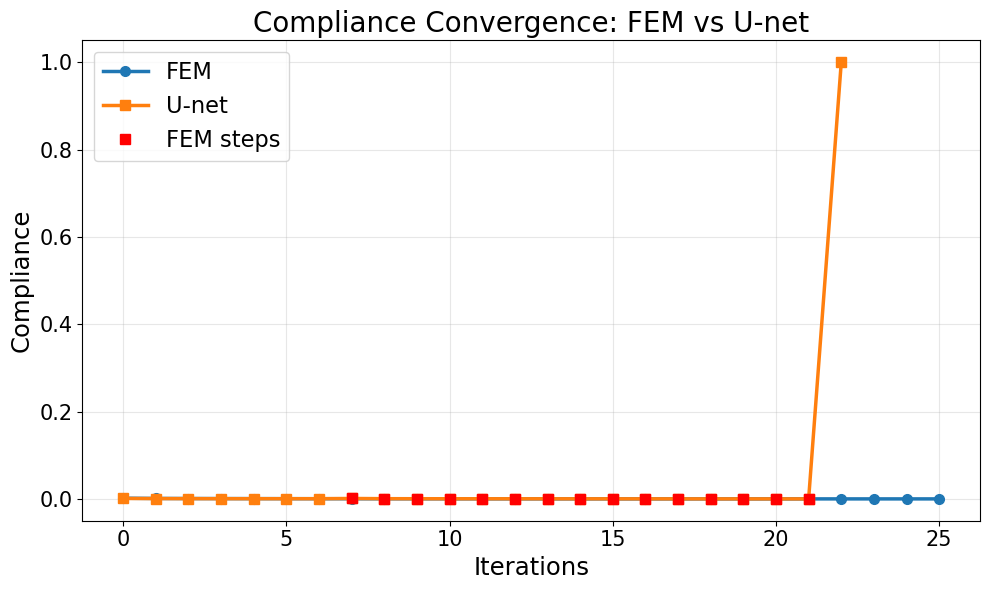

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
UNet_c

array([[0.00000000e+00, 1.95335597e-03],
       [1.00000000e+00, 1.65504077e-03],
       [2.00000000e+00, 1.51677080e-03],
       [3.00000000e+00, 1.43436994e-03],
       [4.00000000e+00, 1.38957659e-03],
       [5.00000000e+00, 1.36705150e-03],
       [6.00000000e+00, 1.37195876e-03],
       [7.00000000e+00, 1.87472673e-03],
       [8.00000000e+00, 1.41968345e-03],
       [9.00000000e+00, 1.31419557e-03],
       [1.00000000e+01, 1.25822949e-03],
       [1.10000000e+01, 1.21433369e-03],
       [1.20000000e+01, 1.18252775e-03],
       [1.30000000e+01, 1.14741712e-03],
       [1.40000000e+01, 1.11915462e-03],
       [1.50000000e+01, 1.08289730e-03],
       [1.60000000e+01, 1.05266250e-03],
       [1.70000000e+01, 1.01475173e-03],
       [1.80000000e+01, 9.88500891e-04],
       [1.90000000e+01, 9.63248604e-04],
       [2.00000000e+01, 9.50172136e-04],
       [2.10000000e+01, 9.40007798e-04],
       [2.20000000e+01, 1.00000000e+00]])

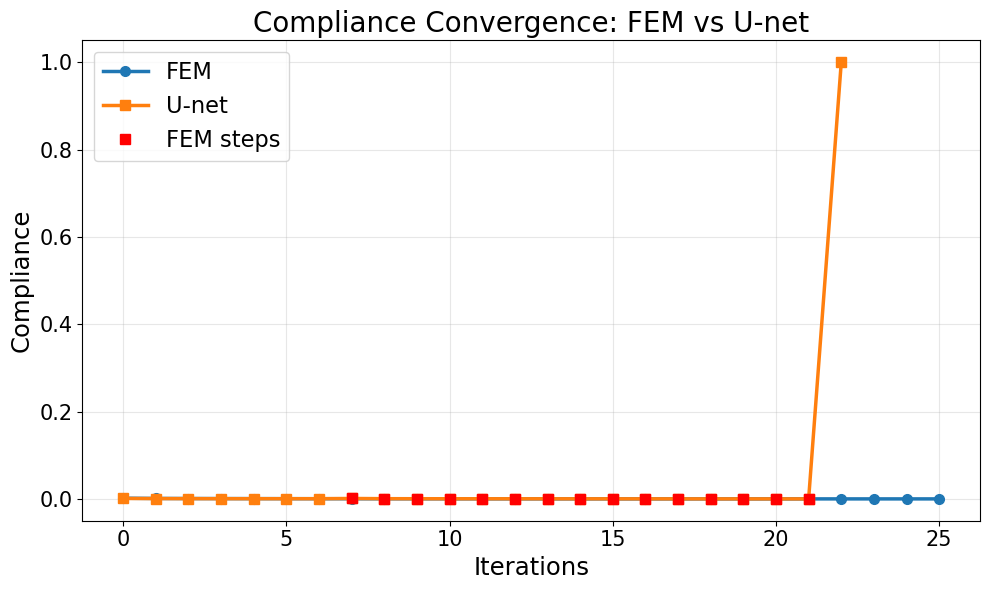

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
UNet_c[:][:-1]

array([[0.00000000e+00, 1.95335597e-03],
       [1.00000000e+00, 1.65504077e-03],
       [2.00000000e+00, 1.51677080e-03],
       [3.00000000e+00, 1.43436994e-03],
       [4.00000000e+00, 1.38957659e-03],
       [5.00000000e+00, 1.36705150e-03],
       [6.00000000e+00, 1.37195876e-03],
       [7.00000000e+00, 1.87472673e-03],
       [8.00000000e+00, 1.41968345e-03],
       [9.00000000e+00, 1.31419557e-03],
       [1.00000000e+01, 1.25822949e-03],
       [1.10000000e+01, 1.21433369e-03],
       [1.20000000e+01, 1.18252775e-03],
       [1.30000000e+01, 1.14741712e-03],
       [1.40000000e+01, 1.11915462e-03],
       [1.50000000e+01, 1.08289730e-03],
       [1.60000000e+01, 1.05266250e-03],
       [1.70000000e+01, 1.01475173e-03],
       [1.80000000e+01, 9.88500891e-04],
       [1.90000000e+01, 9.63248604e-04],
       [2.00000000e+01, 9.50172136e-04],
       [2.10000000e+01, 9.40007798e-04]])

In [ ]:
def visualize_convergence(List_Iterations_Unet, IterationDataset_FEM, List_count_FEM, NETWORK:str, PLOT=True,):
    f_text=1.25 # text size multiplicator 


    FEM_c=[]
    UNet_c=[]

    for i in range(len(IterationDataset_FEM)):
        sample=IterationSample(IterationDataset_FEM, i)
        FEM_c.append([i,sample.c])

    FEM_step_c=[]

    for i,sample in enumerate(List_Iterations_Unet):
        UNet_c.append([i, sample.c.item()])
        if i in List_count_FEM:
            FEM_step_c.append((i, sample.c.item()))

    FEM_c=np.array(FEM_c)
    UNet_c=np.array(UNet_c[:][:-1])

    plt.figure(figsize=(10, 6))
    plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
    plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')
    
    FEM_step_c=np.array(FEM_step_c)

    plt.plot(FEM_step_c[:, 0], FEM_step_c[:, 1], 'rs', markersize=7, label = 'FEM steps')
    
    plt.xlabel('Iterations', fontsize=f_text*14,)
    plt.ylabel('Compliance', fontsize=f_text*14, )
    plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
    plt.legend(fontsize=f_text*13)
    plt.grid(True, alpha=0.3)

    # Set x-axis ticks: integers only, step of 5
    max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
    plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
    plt.yticks(fontsize=f_text*12)
    plt.tight_layout()
    plt.show()

    return FEM_c, UNet_c


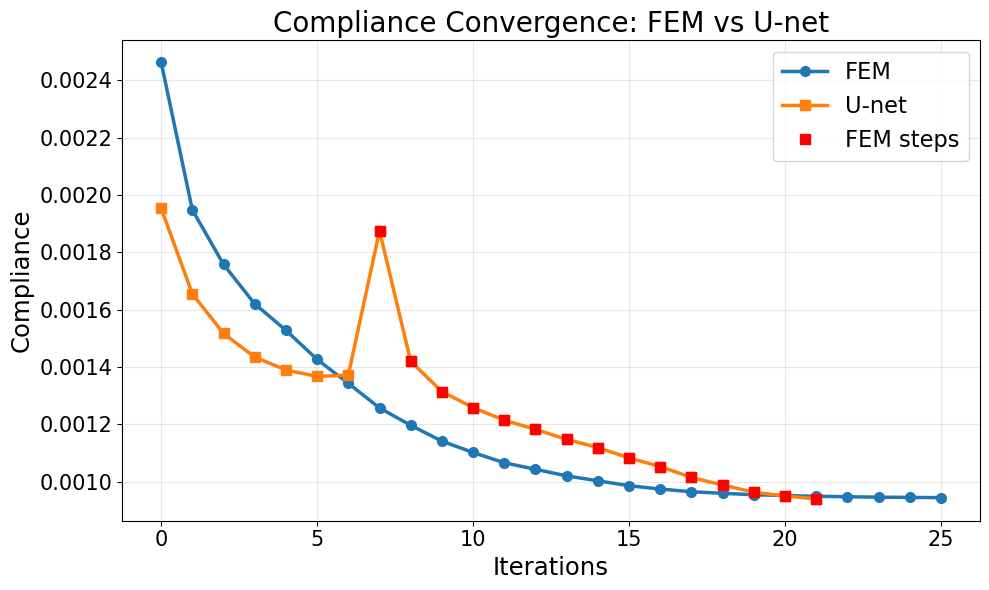

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )

In [ ]:
threshold=0.1

In [ ]:
def visualize_convergence(List_Iterations_Unet, IterationDataset_FEM, List_count_FEM, NETWORK:str, PLOT=True,):
    f_text=1.25 # text size multiplicator 


    FEM_c=[]
    UNet_c=[]

    for i in range(len(IterationDataset_FEM)):
        sample=IterationSample(IterationDataset_FEM, i)
        FEM_c.append([i,sample.c])

    FEM_step_c=[]

    for i,sample in enumerate(List_Iterations_Unet):
        UNet_c.append([i, sample.c.item()])
        if i in List_count_FEM:
            FEM_step_c.append((i, sample.c.item()))

    FEM_c=np.array(FEM_c)
    UNet_c=np.array(UNet_c[:][:-1])

    plt.figure(figsize=(10, 6))
    plt.plot(FEM_c[:, 0], FEM_c[:, 1], 'o-', linewidth=2.5, markersize=7, label='FEM')
    plt.plot(UNet_c[:, 0], UNet_c[:, 1], 's-', linewidth=2.5, markersize=7, label=f'{NETWORK}')
    
    FEM_step_c=np.array(FEM_step_c)

    plt.plot(FEM_step_c[:, 0], FEM_step_c[:, 1], 'rs', markersize=7, label = 'FEM steps')
    
    plt.xlabel('Iterations', fontsize=f_text*14,)
    plt.ylabel('Compliance', fontsize=f_text*14, )
    plt.title(f'Compliance Convergence: FEM vs {NETWORK}', fontsize=f_text*16, )
    plt.legend(fontsize=f_text*13)
    plt.grid(True, alpha=0.3)

    # Set x-axis ticks: integers only, step of 5
    max_iter = max(FEM_c[-1, 0], UNet_c[-1, 0])
    plt.xticks(range(0, int(max_iter) + 5, 5), fontsize=f_text*12)
    plt.yticks(fontsize=f_text*12)
    plt.tight_layout()
    plt.show()

    return FEM_c, UNet_c


In [ ]:

List_count_FEM=[]

# compliance at last iteration of the FEM solution
final_compliance = ds_filtre.c[ID_distrib][ds_filtre.NumIts[ID_distrib] - 1] 

# Rule to alternate between U-Net and FEM iterations
match_Periodic = re.match(r'(\d+) Unet - (\d+) FEM', RULE) # after n Unet iterations, do m FEM iterations
if match_Periodic:
    n_unet = int(match_Periodic.group(1))
    m_fem  = int(match_Periodic.group(2))
    
match_Unet = re.match('Only Unet', RULE) # only Unet iterations
match_FEM = re.match('Only FEM', RULE) # only FEM iterations
match_decreasing = re.match('Decreasing compliance', RULE) # do FEM iterations when compliance increases

ds_iter = IterationDataset(ds_filtre.get_series(ID_distrib))
sample = IterationSample(ds_iter, 0)

List_Relative_Vol_Frac=[sample.Relative_Vol_Frac]
List_mean_densities = [sample.Densities.numpy().mean()]


# Run first topology optimization
next_sample      = GenTopology(sample, eng, model, TYPE=TYPE_FIRST,N_in=N_in)

List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())

List_iterations  = [sample, next_sample]
i                = 1

# Run second iteration before entering the loop to have a valid "previous" sample for convergence checking
sample=next_sample

if TYPE_FIRST == 'FEM':
    List_count_FEM.append(0)

if match_FEM:
    NEXT_TYPE='FEM'
else:
    NEXT_TYPE='UNet'

next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)        
List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
List_mean_densities.append(next_sample.Densities.numpy().mean())
List_iterations.append(next_sample)
i += 1


# loop until max iterations, convergence, or reaching final compliance
while (i < N_max_iterations 
        and (sample.c.item() > final_compliance)
        and not is_converged(List_iterations[-3], List_iterations[-2], tol=1e-4)
        ): 
    
    sample      = next_sample  

    if match_FEM:
        NEXT_TYPE='FEM'
        List_count_FEM.append(i)

    elif match_Periodic and (i-len(List_count_FEM)) % n_unet == 0:
        print(f"  → match_decreasing: sample.c={sample.c.item():.6f}  [-3].c={List_iterations[-3].c.item():.6f}")
        for j in range(m_fem):
            next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)
            List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
            List_mean_densities.append(next_sample.Densities.numpy().mean())
            List_iterations.append(next_sample)
            i += 1
            List_count_FEM.append(i)


    elif (match_decreasing 
        and i>2
        ):
        c_prev = List_iterations[-2].c.item()  # actualisé
        c_pprev = List_iterations[-3].c.item() # actualisé
        print(f"  → c_prev={c_prev:.6f}  c_pprev={c_pprev:.6f}")
        if c_prev > c_pprev * (1 + threshold):
        
            NEXT_TYPE='FEM'
            
            if len(List_count_FEM) > 0: # if no FEM iteration has been done yet, no need to check the last iteration type
                # Ckeck if last iteration was already FEM
                if List_count_FEM[-1]==i-1: 
                    # if last iteration was already FEM, do not delete it but just do another FEM iteration
                    List_count_FEM.append(i)

                else: 
                    # if last iteration was UNet, do not add a FEM iteration but just replace it with a FEM iteration
                    del List_iterations[-1] 
                    del List_Relative_Vol_Frac[-1]
                    del List_mean_densities[-1]
                    List_count_FEM.append(i-1) # add the FEM iteration at the same index as the UNet iteration that is being replaced
                    
                    sample = List_iterations[-1] # update sample to the last iteration
                    next_sample = GenTopology(sample, eng, model, TYPE='FEM',N_in=N_in)    
                    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
                    List_mean_densities.append(next_sample.Densities.numpy().mean())
                    List_iterations.append(next_sample)
            else:
                # if no FEM iteration has been done yet, just do a FEM iteration without checking the last iteration type
                List_count_FEM.append(i)
                    
        else:
            NEXT_TYPE='UNet'


    else:
        NEXT_TYPE='UNet'

    # Common actualisation for both UNet and FEM iterations
    next_sample = GenTopology(sample, eng, model, TYPE=NEXT_TYPE,N_in=N_in)    
    List_Relative_Vol_Frac.append(next_sample.Relative_Vol_Frac)
    List_mean_densities.append(next_sample.Densities.numpy().mean())
    List_iterations.append(next_sample)
    i += 1
    print(f"i={i} — TYPE={NEXT_TYPE} — sample.c={sample.c.item():.6f}")
    print(f"converged={is_converged(sample, next_sample, tol=1e-4)}")
    print(f"c <= final: {next_sample.c.item() <= final_compliance}\n")           
    

i=3 — TYPE=UNet — sample.c=0.001517
converged=False
c <= final: False

  → c_prev=0.001517  c_pprev=0.001655
i=4 — TYPE=UNet — sample.c=0.001434
converged=False
c <= final: False

  → c_prev=0.001434  c_pprev=0.001517
i=5 — TYPE=UNet — sample.c=0.001390
converged=False
c <= final: False

  → c_prev=0.001390  c_pprev=0.001434
i=6 — TYPE=UNet — sample.c=0.001367
converged=False
c <= final: False

  → c_prev=0.001367  c_pprev=0.001390
i=7 — TYPE=UNet — sample.c=0.001372
converged=False
c <= final: False

  → c_prev=0.001372  c_pprev=0.001367
i=8 — TYPE=UNet — sample.c=0.001361
converged=False
c <= final: False

  → c_prev=0.001361  c_pprev=0.001372
i=9 — TYPE=UNet — sample.c=0.001383
converged=False
c <= final: False

  → c_prev=0.001383  c_pprev=0.001361
i=10 — TYPE=UNet — sample.c=0.001363
converged=False
c <= final: False

  → c_prev=0.001363  c_pprev=0.001383
i=11 — TYPE=UNet — sample.c=0.001328
converged=False
c <= final: False

  → c_prev=0.001328  c_pprev=0.001363
i=12 — TYPE=UNet 

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

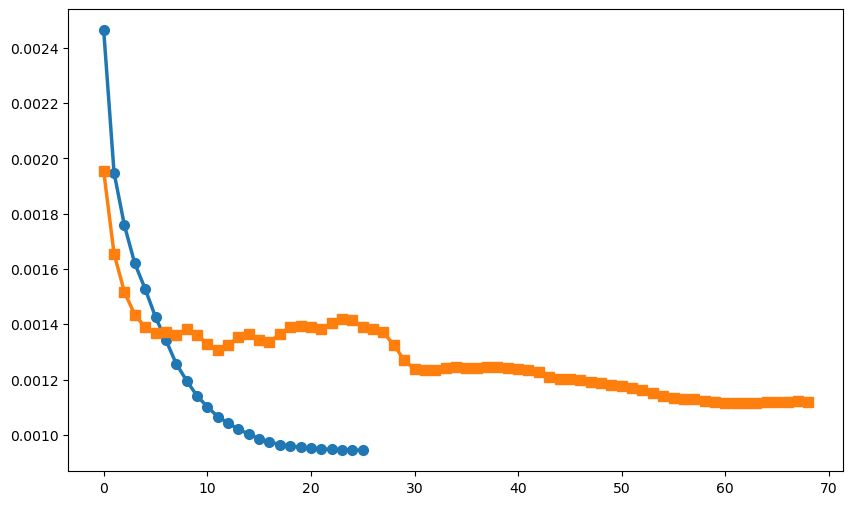

In [ ]:
# FEM_c, UNet_c = statistical_convergence(
#     List_List_iterations, 
#     IterData_FEM, 
#     NETWORK=NETWORK, 
#     PLOT=True, 
#     TYPE='std'
#     )




ds_iter=IterationDataset(ds_filtre.get_series(ID_distrib))

# for i in range(len(ds_iter)):
#     sample=IterationSample(ds_iter,i)
#     print('sample ',i)
#     sample.plot_inputs()



FEM_c, UNet_c = visualize_convergence(
    List_iterations[:-1], 
    ds_iter, 
    List_count_FEM,
    NETWORK=NETWORK, 
    )